## Adding stochasticity 
To the most variable cell type so that I can see if the model fits the data better. 

In [1]:
# fitting to the data that it T11 line (more resistant to immune checkpoint treatment), UV/Apobec (so mutagen treated), immune checkpoint therapy administered 
import scipy
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
from matplotlib import pyplot as plt


## Defining our ODE system

In [11]:
def cancer_ode(t,y,lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC_comb,
               K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr_comb,d_T8,
              lambda_T8_comb,K_D,K_Tr):
    C,D,N,Tr,T8 = y
    dC = lambda_C*C*(1-C/C_M) - eta_8*T8*C - eta_8*N*C-d_C*C
    dD = lambda_DC_comb*C/(C+K_C)-d_D*D
    dN = sigma_N - d_N*N - gamma_N*Tr*N + a_C*N*C/(1+C/beta_1 + N/beta_2)
    dTr = -d_Tr*Tr + lambda_Tr_comb*C/(K_C+C)
    dT8 = -d_T8 * T8 + lambda_T8_comb*D/(K_D+D)/(1+Tr/K_Tr)
    return np.array((dC,dD,dN,dTr,dT8,))

In [12]:
def cancer_ode_parametrised(t, y, p):
    return cancer_ode(
        t, y, 
        p['lambda_C'], p['C_M'], p['eta_8'], p['eta_N'], p['d_C'], 
        p['lambda_DC_comb'], p['K_C'], p['d_D'], p['sigma_N'], 
        p['d_N'], p['gamma_N'], p['a_C'], p['beta_1'], p['beta_2'], 
        p['d_Tr'], p['lambda_Tr_comb'], p['d_T8'], p['lambda_T8_comb'], 
        p['K_D'], p['K_Tr']
    ) 

# T11 cell line 

In [2]:
df = pd.read_csv("Mammary_data_response_1e8.csv")
df_T11 = df[df['Cell_Line'] == 'T11']
df_T11_ICI = df_T11[df_T11['Mouse_treatment']!='no_treatment']
df_T11_ICI

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,ICB_study,GSM_ID,Cell_Line,Cancer_type,Study_ID
166,SRX5100724,0.001480,0.000810,0.000054,0.000361,antiPD1; antiCTLA4;,Apobec_end,end,R,GSM3554847,T11,"Mammary cancer, NOS",GSE124821
169,SRX5100642,0.002127,0.001080,0.000074,0.000376,antiPD1; antiCTLA4;,Apobec_end,end,R,GSM3554850,T11,"Mammary cancer, NOS",GSE124821
171,SRX5100638,0.005433,0.001761,0.000051,0.000530,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554852,T11,"Mammary cancer, NOS",GSE124821
172,SRX5100632,0.007120,0.002415,0.000192,0.000578,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554853,T11,"Mammary cancer, NOS",GSE124821
173,SRX5100675,0.005026,0.001591,0.000043,0.000476,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554854,T11,"Mammary cancer, NOS",GSE124821
175,SRX5100859,0.001926,0.000846,0.000024,0.000324,antiPD1; antiCTLA4;,Apobec_end,end,R,GSM3554856,T11,"Mammary cancer, NOS",GSE124821
177,SRX5100857,0.004220,0.001382,0.000040,0.000431,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554858,T11,"Mammary cancer, NOS",GSE124821
180,SRX5100867,0.001831,0.000895,0.000002,0.000430,antiPD1; antiCTLA4;,Apobec_end,end,R,GSM3554861,T11,"Mammary cancer, NOS",GSE124821
186,SRX5100790,0.003833,0.001607,0.000578,0.000508,antiPD1; antiCTLA4;,UV_day7,day7,R,GSM3554883,T11,"Mammary cancer, NOS",GSE124821
187,SRX5100789,0.005915,0.001772,0.000768,0.000565,antiPD1; antiCTLA4;,UV_day7,day7,R,GSM3554884,T11,"Mammary cancer, NOS",GSE124821


In [3]:
# df_T11_ICI is our data to fit 
# I am going to recreate the current ODE model fit here using the current best parameters that Ilina has found 

## T11 : Immune checkpoint +ve, UV/Apobec treated data

In [4]:
day = 'day3'
df_T11_ICI[df_T11_ICI['Condition'].str.contains('_'+day)]

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,ICB_study,GSM_ID,Cell_Line,Cancer_type,Study_ID
171,SRX5100638,0.005433,0.001761,0.000051,0.000530,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554852,T11,"Mammary cancer, NOS",GSE124821
172,SRX5100632,0.007120,0.002415,0.000192,0.000578,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554853,T11,"Mammary cancer, NOS",GSE124821
173,SRX5100675,0.005026,0.001591,0.000043,0.000476,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554854,T11,"Mammary cancer, NOS",GSE124821
177,SRX5100857,0.004220,0.001382,0.000040,0.000431,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554858,T11,"Mammary cancer, NOS",GSE124821
218,SRX5100850,0.001531,0.000771,0.000056,0.000200,antiPD1; antiCTLA4;,UV_day3,day3,R,GSM3554915,T11,"Mammary cancer, NOS",GSE124821
219,SRX5100851,0.003212,0.001296,0.000000,0.000543,antiPD1; antiCTLA4;,UV_day3,day3,R,GSM3554916,T11,"Mammary cancer, NOS",GSE124821
220,SRX5100601,0.002766,0.001135,0.000137,0.000344,antiPD1; antiCTLA4;,UV_day3,day3,R,GSM3554917,T11,"Mammary cancer, NOS",GSE124821


In [9]:
# the scatter data for the T11 ICI data 
#treatment with mutagen
mutagen_Ds = []
mutagen_NKs = []
mutagen_T8s = []
mutagen_Tregs = []

scatter_mutagen_Ds = []
scatter_mutagen_NKs = []
scatter_mutagen_Tregs = []
scatter_mutagen_T8s = []
scatter_mutagen_times = []

quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]
time_points = ["day3","day7","end"]

for day in time_points:
    day_df = df_T11_ICI[df_T11_ICI['Condition'].str.contains('_'+day)]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    stds = day_df.filter(items=quanTIseq_cols).std()
    print("Averages:")
    print(averages)
    

    # print(type(day_df.filter(items=quanTIseq_cols).mean()))
    mutagen_Ds.append(averages["Dendritic_quanTIseq"])
    mutagen_NKs.append(averages["NK_quanTIseq"])
    mutagen_T8s.append(averages["T.CD8_quanTIseq"])
    mutagen_Tregs.append(averages["Tregs_quanTIseq"])
    mutagen_total = sum(averages)
    
    print(mutagen_total)
    
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_mutagen_Ds.append(i)
                scatter_mutagen_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_mutagen_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_mutagen_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_mutagen_T8s.append(i)

# by printing the sds, I can see that the most variable type of cell here is 




Number of replicates 7
Averages:
Dendritic_quanTIseq    0.004187
NK_quanTIseq           0.001479
T.CD8_quanTIseq        0.000074
Tregs_quanTIseq        0.000443
dtype: float64
0.006182992517142857

Number of replicates 8
Averages:
Dendritic_quanTIseq    0.004660
NK_quanTIseq           0.001701
T.CD8_quanTIseq        0.000798
Tregs_quanTIseq        0.000610
dtype: float64
0.0077687861

Number of replicates 9
Averages:
Dendritic_quanTIseq    0.002484
NK_quanTIseq           0.001149
T.CD8_quanTIseq        0.000036
Tregs_quanTIseq        0.000457
dtype: float64
0.004125642369866667


In [10]:

averages = day_df.filter(items=quanTIseq_cols).mean()
stds = day_df.filter(items=quanTIseq_cols).std()

cv = stds / averages

print("Averages:")
print(averages)

print("Standard deviations:")
print(stds)

print("Coefficient of variation (CV):")
print(cv)

# from this I can see that the most variable cell type is the CD8 T+ cells 

Averages:
Dendritic_quanTIseq    0.002484
NK_quanTIseq           0.001149
T.CD8_quanTIseq        0.000036
Tregs_quanTIseq        0.000457
dtype: float64
Standard deviations:
Dendritic_quanTIseq    0.000745
NK_quanTIseq           0.000300
T.CD8_quanTIseq        0.000033
Tregs_quanTIseq        0.000108
dtype: float64
Coefficient of variation (CV):
Dendritic_quanTIseq    0.300045
NK_quanTIseq           0.261615
T.CD8_quanTIseq        0.915383
Tregs_quanTIseq        0.235670
dtype: float64


/home/participant/miniforge3/envs/cancer_sim/lib/python3.11/site-packages/scipy/integrate/_ivp/ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `abs_tol`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


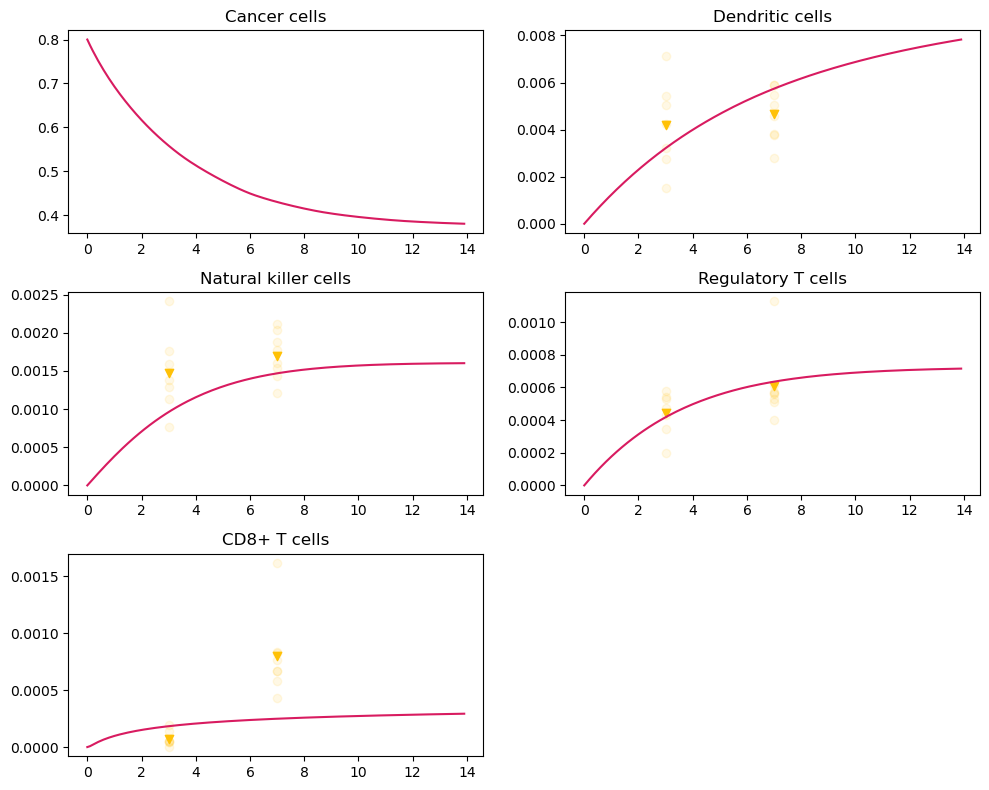

In [13]:
# define the parameters you will be using!!

mutagen_best_params = {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0005, 'd_N': 0.15, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.00025, 'd_T8': 0.075, 'lambda_T8_comb': 0.00125, 'K_Tr': 3e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}

mutagen_best_params_new = {
    'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 
    'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004, # lambda DC comb was 0.002 -> 0.0095 then changed it back, sigma N was 0.0004
    'd_N': 0.16, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 
    'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.075, 'lambda_T8_comb': 0.0009, # lambda 78 comb was 0.00125 -> 0.00045, lambda TR was 0.0025
    'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, #Ktreg was 3e-05
    'Tr_init': 0.0, 'T8_init': 0.0
}

# code to plot the ODE fitted parameters against the data 

c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)

tspan = (0.0,14.0,)
C_init     = mutagen_best_params_new['C_init']
D_init     = mutagen_best_params_new['D_init']
N_init     = mutagen_best_params_new['N_init']
Tr_init    = mutagen_best_params_new['Tr_init']
T8_init    = mutagen_best_params_new['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (mutagen_best_params_new,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.set_title('Cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1)
D_cells.set_title('Dendritic cells')
D_cells.scatter([3.0,7.0],mutagen_Ds[:2],alpha=1.0,marker ='v',color = c3)
D_cells.scatter(scatter_mutagen_times,scatter_mutagen_Ds,alpha=0.1,color = c3)


NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_mutagen_times,scatter_mutagen_NKs,alpha=0.1,color = c3)
NK_cells.scatter([3,7],mutagen_NKs[:2],alpha=1.0,marker ='v',color = c3)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_mutagen_times,scatter_mutagen_Tregs,alpha=0.1,color = c3)
Treg.scatter([3,7],mutagen_Tregs[:2],alpha=1.0,marker ='v',color = c3)
# {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_mutagen_times,scatter_mutagen_T8s,alpha=0.1,color = c3)
T8.scatter([3,7],mutagen_T8s[:2],alpha=1.0,marker ='v',color = c3)


extra_plot = ax[2,1]
extra_plot.set_visible(False)


plt.tight_layout()
plt.show()

## Implementation of the Gillespie algorithm to introduce stochasticity 

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def gillespie_simulation(params, t_max, initial_counts, scale): # this function needs you to pass parameters, initial states and the maximum time
    # the scale here is 1000 and this is because we need to multiply these proportions into discrete numbers 
    # this is cos the gillespie algorithm is basically based on birth and death processes so we need whole numbers 
    state = np.array([
        initial_counts['C_init'] * scale,
        initial_counts['D_init'] * scale,
        initial_counts['N_init'] * scale,
        initial_counts['Tr_init'] * scale,
        initial_counts['T8_init'] * scale
    ], dtype=float)
    
    t = 0.0
    t_history = [t] # recording time 
    y_history = [state.copy()] # recording the simulated data 
    
    # parameters 
    p = params
    
    while t < t_max:
        C, D, N, Tr, T8 = state
        if C + D + N + Tr + T8 <= 0: # Don't want any of these numbers to be negative 
            break

        # rates
        # 1 : cancer cells
        # need to split the ODE term into birth and death (the positive and negative parts)
        r1_birth = p['lambda_C'] * C
        r1_death = (p['lambda_C'] * (C**2) / (p['C_M'] * scale)) + (p['eta_8'] * T8 * C / scale) + (p['eta_N'] * N * C / scale) + (p['d_C'] * C)
        
        # 2 : dendritic cells
        r2_rec = (p['lambda_DC_comb'] * scale * C) / (C + p['K_C'] * scale)
        r2_death = p['d_D'] * D
        
        # 3 : NK cells 
        r3_growth = (p['sigma_N'] * scale) + (p['a_C'] * N * C / (scale + C/p['beta_1'] + N/p['beta_2']))
        r3_death = (p['d_N'] * N) + (p['gamma_N'] * Tr * N / scale)
        
        # 4 : Tregs
        r4_rec = (p['lambda_Tr_comb'] * scale * C) / (p['K_C'] * scale + C)
        r4_death = p['d_Tr'] * Tr
        
        # 5 : CD8+ T cells 
        r5_act = (p['lambda_T8_comb'] * scale * D / (p['K_D'] * scale + D)) / (1 + (Tr / (p['K_Tr'] * scale)))
        r5_death = p['d_T8'] * T8

        propensities = np.array([r1_birth, r1_death, r2_rec, r2_death, r3_growth, r3_death, r4_rec, r4_death, r5_act, r5_death])
        a_total = np.sum(propensities)
        
        if a_total <= 0: break # no neg numbers

        # time with exponential distribution
        dt = -np.log(np.random.random()) / a_total # so this reaction makes the time steps random not at a fixed rate 
        # dividing by the a total allows us to say that if a lot of reactions are posisble then the next reaction happens sooner 
        t += dt
        
        # choose reaction
        r_idx = np.searchsorted(np.cumsum(propensities), np.random.random() * a_total)
        # cumsum is running total of the ratios of each cell 
        # random a total picks a random point along all the reactions and then sorted thing picks which reaction you ended up in 
        
        # update with either a birth or a death of state (+1 or -1)
        updates = [
            (0, 1), (0, -1), # C
            (1, 1), (1, -1), # D
            (2, 1), (2, -1), # NK
            (3, 1), (3, -1), # Tr
            (4, 1), (4, -1)  # T8
        ]
        var_idx, change = updates[r_idx]
        state[var_idx] += change
        
        # record the history
        t_history.append(t)
        y_history.append(state.copy())

    return np.array(t_history), np.array(y_history) / scale # need to rescale down 



The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


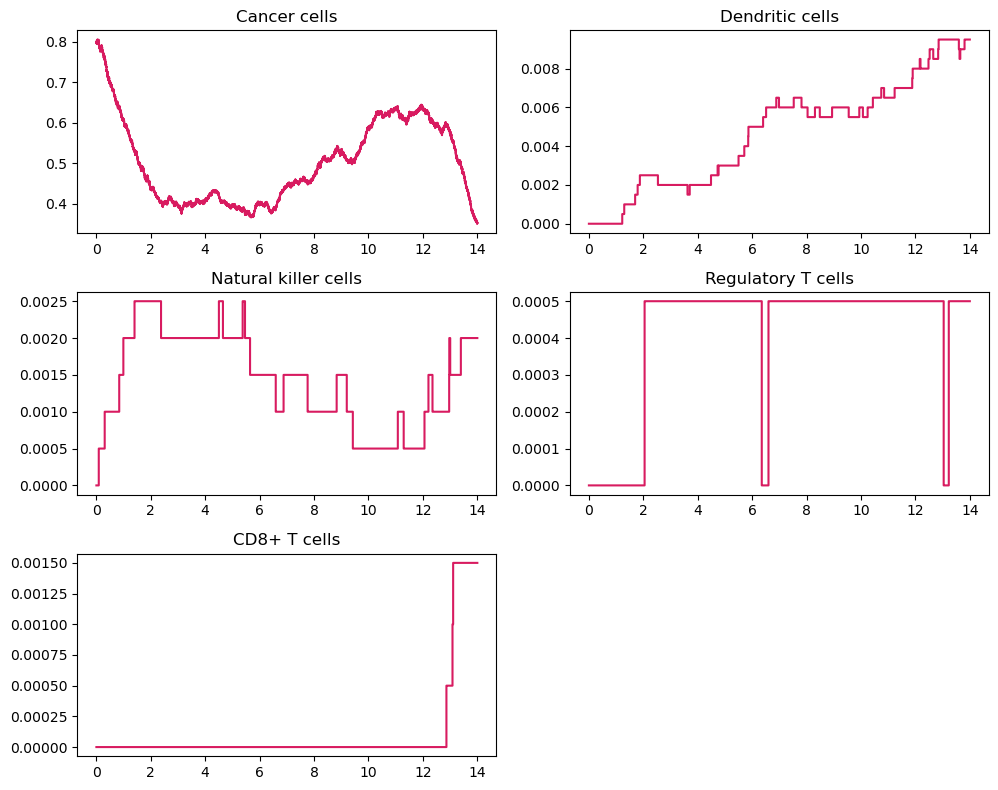

In [15]:
# plotting the gillespie algorithm output

# scale determines how noisy the lines are 
t_g, y_g = gillespie_simulation(mutagen_best_params_new, 14.0, mutagen_best_params_new, scale=2000) # keep scale >1000 

# colour
#c1 = (216/255, 27/255, 96/255)

fig, ax = plt.subplots(3, 2, figsize=(10, 8))
titles = ['Cancer cells', 'Dendritic cells', 'Natural killer cells', 'Regulatory T cells', 'CD8+ T cells']
indices = [(0,0), (0,1), (1,0), (1,1), (2,0)]

for i, (r, c) in enumerate(indices):
    # 'step' plot so we can see discrete jumps 
    ax[r, c].step(t_g, y_g[:, i], color=c1, where='post')
    ax[r, c].set_title(titles[i])

ax[2, 1].set_visible(False)
plt.tight_layout()
plt.show()

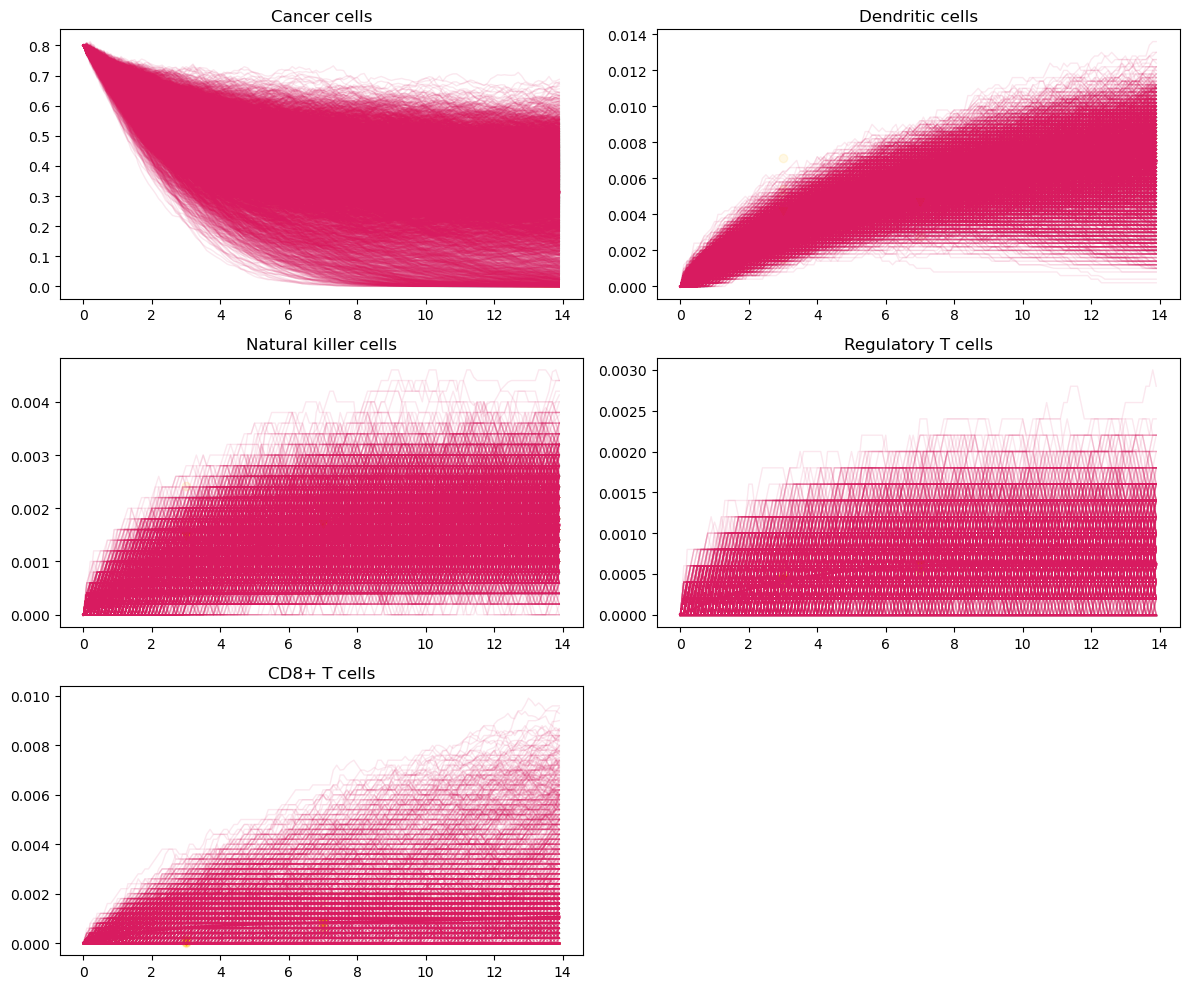

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def run_multiple_gillespie(params, t_eval, n_sims, scale):
    all_results = []
    
    for _ in range(n_sims):
        t_hist, y_hist = gillespie_simulation(params, t_eval[-1], params, scale=scale)
        y_interp = np.zeros((len(t_eval), 5))
        for i in range(5):
            y_interp[:, i] = np.interp(t_eval, t_hist, y_hist[:, i])
        all_results.append(y_interp)
        
    return np.array(all_results)

# plot
t_eval = np.arange(0.0, 14.0, 0.1)
n_sims = 5000
scale = 5000

# run the multiple gillespies 
sim_data = run_multiple_gillespie(mutagen_best_params_new, t_eval, n_sims=n_sims, scale=scale)
mean_sim = np.mean(sim_data, axis=0) # also want to calculate the mean simulation

# color
c1 = (216/255, 27/255, 96/255) # pink 
c3 = (255/255, 193/255, 7/255) # yellow

fig, ax = plt.subplots(3, 2, figsize=(12, 10))

titles = ['Cancer cells', 'Dendritic cells', 'Natural killer cells', 'Regulatory T cells', 'CD8+ T cells']
indices = [(0,0), (0,1), (1,0), (1,1), (2,0)]
# data 
scatter_data = [None, scatter_mutagen_Ds, scatter_mutagen_NKs, scatter_mutagen_Tregs, scatter_mutagen_T8s]
v_markers = [None, mutagen_Ds, mutagen_NKs, mutagen_Tregs, mutagen_T8s]

for i, (r, c) in enumerate(indices):
    axis = ax[r, c]
    
    # plot each individual run in a transparent pink
    for s in range(n_sims):
        axis.plot(t_eval, sim_data[s, :, i], color=c1, alpha=0.1, linewidth=1)
    
    # mean of stochastic runs plotted in a bold pink
    axis.plot(t_eval, mean_sim[:, i], color=c1, linewidth=2, label='Stochastic Mean')
    
    # scattter points are plotted as a light yellow
    if scatter_data[i] is not None:
        axis.scatter(scatter_mutagen_times, scatter_data[i], alpha=0.1, color=c3)
    
    # v markers added 
    if v_markers[i] is not None:
        axis.scatter([3.0, 7.0], v_markers[i][:2], alpha=1.0, marker='v', color=c3)

    axis.set_title(titles[i])

ax[2, 1].set_visible(False)
plt.tight_layout()
plt.savefig("GSP_T11_ICI_UVA_indv.pdf", format='pdf', dpi=300)
plt.show()

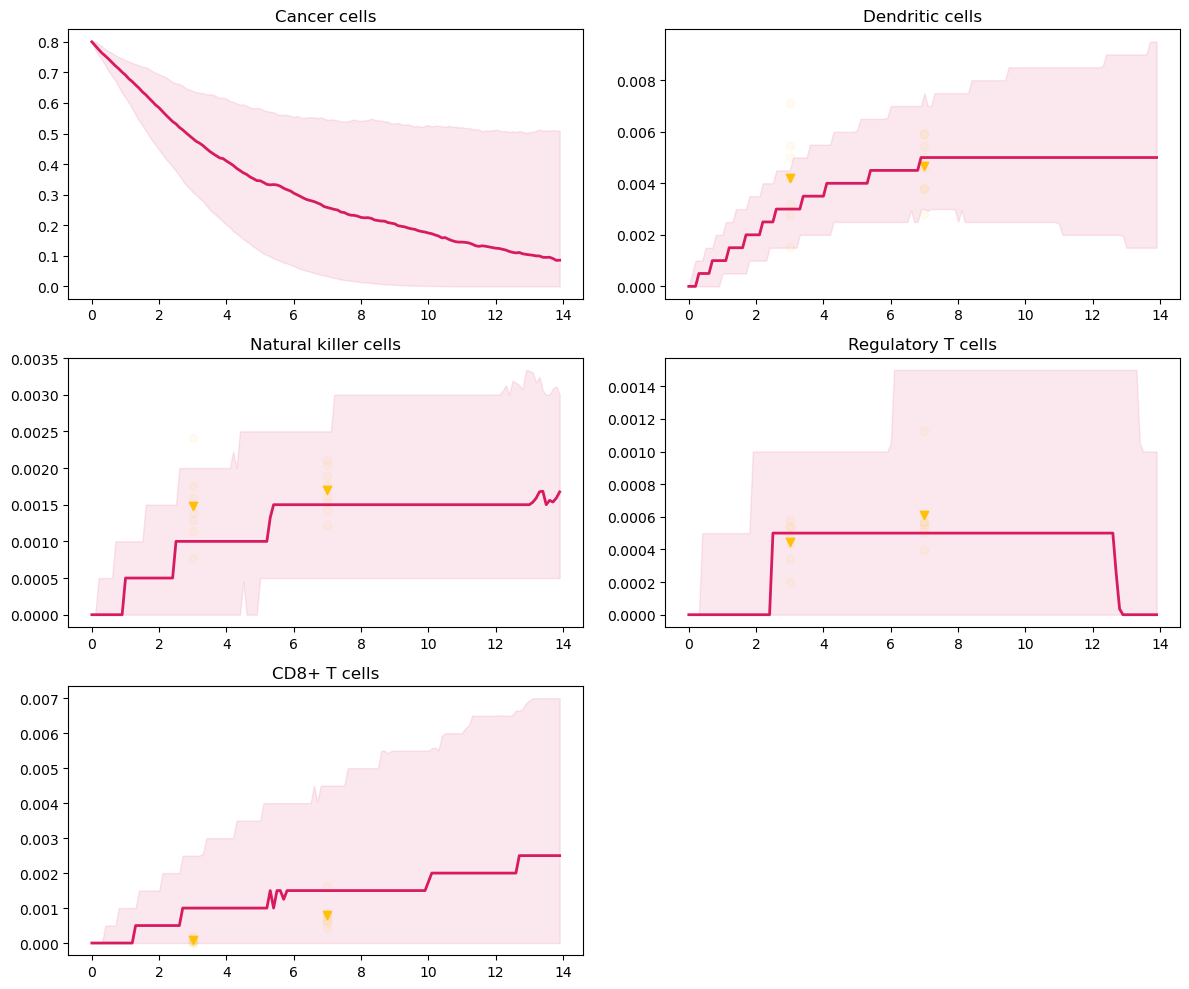

In [18]:


fig, ax = plt.subplots(3, 2, figsize=(12, 10))

titles = ['Cancer cells', 'Dendritic cells', 'Natural killer cells', 'Regulatory T cells', 'CD8+ T cells']
indices = [(0,0), (0,1), (1,0), (1,1), (2,0)]
# data
scatter_data = [None, scatter_mutagen_Ds, scatter_mutagen_NKs, scatter_mutagen_Tregs, scatter_mutagen_T8s]
v_markers = [None, mutagen_Ds, mutagen_NKs, mutagen_Tregs, mutagen_T8s]



for i, (r, c) in enumerate(indices):
    axis = ax[r, c]
    
    # simulation stats
    median_sim = np.percentile(sim_data[:, :, i], 50, axis=0)
    lower_bound = np.percentile(sim_data[:, :, i], 10, axis=0) # 10th percentile
    upper_bound = np.percentile(sim_data[:, :, i], 90, axis=0) # 90th percentile
    
    # the transparent area is where 80% of the sims fall 
    axis.fill_between(t_eval, lower_bound, upper_bound, color=c1, alpha=0.1, label='80% Interval')
    
    # median simulation plotted in bold 
    axis.plot(t_eval, median_sim, color=c1, linewidth=2, label='Stochastic Median')
    
    # scatter of data
    if scatter_data[i] is not None:
        axis.scatter(scatter_mutagen_times, scatter_data[i], alpha=0.05, color=c3)
    if v_markers[i] is not None:
        axis.scatter([3.0, 7.0], v_markers[i][:2], alpha=1.0, marker='v', color=c3)

    axis.set_title(titles[i])

ax[2, 1].set_visible(False)
plt.tight_layout()
# save as PDF
plt.savefig("GSP_T11_ICI_UVA_hue.pdf", format='pdf', dpi=300)
plt.show()



In [73]:
df_T11_ICI.to_csv("T11_ICI.csv", index=False)